In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Download pretrained IResNet50 backbone (MS1MV3, ArcFace, fp16)
import os
_weights = "/content/ms1mv3_arcface_r50_fp16.pth"
if not os.path.exists(_weights):
    !wget -q --show-progress -O /content/ms1mv3_arcface_r50_fp16.pth \
        "https://huggingface.co/camenduru/show/resolve/main/models/arcface/ms1mv3_arcface_r50_fp16.pth"
    print(f"Pobrano wagi: {_weights} ({os.path.getsize(_weights) / 1e6:.0f} MB)")
else:
    print(f"Wagi już pobrane: {_weights}")

Mounted at /content/drive
/content/ms1mv3_arc 100%[===================>] 166.59M   276MB/s    in 0.6s    
Pobrano wagi: /content/ms1mv3_arcface_r50_fp16.pth (175 MB)


## Konfiguracja

In [2]:
from pathlib import Path

DRIVE_BASE = Path("/content/drive/MyDrive")

# --- Ścieżki (możliwość podania własnych) ---
DATA_DIR = DRIVE_BASE / "biometrics/face_authorization/data"
CROPPED_ZIP = DATA_DIR / "img_align_celeba_cropped.zip"
IDENTITY_FILE = DATA_DIR / "identity_CelebA.txt"
RESULTS_DIR = DRIVE_BASE / "biometrics/face_authorization/results"

# Katalog roboczy (lokalny Colab — szybsze I/O niż Drive)
CROPPED_DIR = Path("/content/cropped_images")

# Pretrained backbone weights
PRETRAINED_WEIGHTS = Path("/content/ms1mv3_arcface_r50_fp16.pth")

# --- Podział danych ---
MIN_IMAGES_PER_IDENTITY = 5
TRAIN_RATIO = 0.70
DEV_RATIO = 0.15
TEST_RATIO = 0.15

# --- ArcFace ---
EMBEDDING_SIZE = 512
ARCFACE_S = 64.0
ARCFACE_M = 0.5

# --- Trening: Faza 1 (Linear Probing) ---
PHASE1_LR = 1e-3
PHASE1_EPOCHS = 5

# --- Trening: Faza 2 (Full Fine-tuning) ---
PHASE2_LR = 1e-5
PHASE2_EPOCHS = 30

# --- Ewaluacja ---
NUM_POSITIVE_PAIRS = 3000
NUM_NEGATIVE_PAIRS = 3000

# --- Inne ---
BATCH_SIZE = 256
NUM_WORKERS = 0
SEED = 42

In [3]:
import math
import random
import zipfile
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Reprodukowalność
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Przygotowanie danych

In [4]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CROPPED_DIR.mkdir(parents=True, exist_ok=True)

# Rozpakowanie ZIP do katalogu lokalnego
existing_files = list(CROPPED_DIR.rglob("*_cropped.jpg"))
if not existing_files:
    print(f"Rozpakowywanie {CROPPED_ZIP} ...")
    with zipfile.ZipFile(CROPPED_ZIP, "r") as zf:
        zf.extractall(CROPPED_DIR)
    existing_files = list(CROPPED_DIR.rglob("*_cropped.jpg"))
    print(f"Rozpakowano {len(existing_files)} obrazów")
else:
    print(f"Obrazy już rozpakowane: {len(existing_files)} plików")

# Wykrycie katalogu ze zdjęciami (ZIP może zawierać podkatalog)
IMG_DIR = existing_files[0].parent
print(f"Katalog obrazów: {IMG_DIR}")

Rozpakowywanie /content/drive/MyDrive/biometrics/face_authorization/data/img_align_celeba_cropped.zip ...
Rozpakowano 405198 obrazów
Katalog obrazów: /content/cropped_images/cropped


## Podział zbioru danych (Open-Set)

Podział wykonywany jest po **unikalnych tożsamościach** — zdjęcia tej samej osoby nigdy nie znajdą się w różnych zbiorach (train / dev / test).

In [5]:
# Wczytanie mapowania: filename.jpg -> identity_id
identity_to_files = defaultdict(list)

with open(IDENTITY_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        orig_filename, identity_id = parts[0], int(parts[1])
        cropped_name = Path(orig_filename).stem + "_cropped.jpg"
        if (IMG_DIR / cropped_name).exists():
            identity_to_files[identity_id].append(cropped_name)

print(f"Tożsamości ogółem: {len(identity_to_files)}")
print(f"Obrazów ogółem: {sum(len(v) for v in identity_to_files.values())}")

# Filtracja: min. MIN_IMAGES_PER_IDENTITY zdjęć na tożsamość
filtered = {
    k: v for k, v in identity_to_files.items()
    if len(v) >= MIN_IMAGES_PER_IDENTITY
}
print(f"\nPo filtracji (>= {MIN_IMAGES_PER_IDENTITY} zdjęć):")
print(f"  Tożsamości: {len(filtered)}")
print(f"  Obrazów: {sum(len(v) for v in filtered.values())}")

# Podział po tożsamościach (Open-Set)
all_ids = sorted(filtered.keys())
train_ids, temp_ids = train_test_split(
    all_ids, test_size=(DEV_RATIO + TEST_RATIO), random_state=SEED
)
dev_ids, test_ids = train_test_split(
    temp_ids, test_size=TEST_RATIO / (DEV_RATIO + TEST_RATIO), random_state=SEED
)

# Mapowanie train identity -> label (0..N-1)
train_id_to_label = {id_: label for label, id_ in enumerate(sorted(train_ids))}
num_train_classes = len(train_id_to_label)

# Listy (filename, label/identity) per split
train_data = [(f, train_id_to_label[id_]) for id_ in train_ids for f in filtered[id_]]
dev_data = [(f, id_) for id_ in dev_ids for f in filtered[id_]]
test_data = [(f, id_) for id_ in test_ids for f in filtered[id_]]

print(f"\nPodział (Open-Set):")
print(f"  Train: {len(train_ids)} tożsamości, {len(train_data)} obrazów")
print(f"  Dev:   {len(dev_ids)} tożsamości, {len(dev_data)} obrazów")
print(f"  Test:  {len(test_ids)} tożsamości, {len(test_data)} obrazów")
print(f"  Klasy treningowe (num_classes): {num_train_classes}")

Tożsamości ogółem: 10177
Obrazów ogółem: 202599

Po filtracji (>= 5 zdjęć):
  Tożsamości: 9343
  Obrazów: 200288

Podział (Open-Set):
  Train: 6540 tożsamości, 139885 obrazów
  Dev:   1401 tożsamości, 30465 obrazów
  Test:  1402 tożsamości, 29938 obrazów
  Klasy treningowe (num_classes): 6540


In [17]:
# Zapis podziału tożsamości do plików
for name, ids in [("train_split.txt", train_ids), ("valid_split.txt", dev_ids), ("test_split.txt", test_ids)]:
    path = RESULTS_DIR / name
    with open(path, "w") as f:
        for id_ in sorted(ids):
            f.write(f"{id_}\n")
    print(f"Zapisano {path.name}: {len(ids)} tożsamości")

Zapisano train_split.txt: 6540 tożsamości
Zapisano valid_split.txt: 1401 tożsamości
Zapisano test_split.txt: 1402 tożsamości


## Dataset i DataLoader

In [6]:
class CelebADataset(Dataset):
    """Dataset cropowanych zdjęć CelebA."""

    def __init__(self, data, img_dir, transform=None):
        self.data = data          # [(filename, label/id)]
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filename, label = self.data[idx]
        image = Image.open(self.img_dir / filename).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = CelebADataset(train_data, IMG_DIR, train_transform)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Train batches: {len(train_loader)}")

Train dataset: 139885 samples
Train batches: 546


## Architektura modelu ArcFace

**Backbone:** IResNet50 (pretrained) → embedding 512-dim
**Głowica:** ArcMarginProduct — additive angular margin loss (s=64, m=0.5)
**Strata:** ArcFace Loss = ArcMarginProduct + CrossEntropyLoss

In [7]:
class IBasicBlock(nn.Module):
    """Blok residualny IResNet (BN-Conv-BN-PReLU-Conv-BN)."""
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-05)
        self.conv1 = nn.Conv2d(inplanes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-05)
        self.prelu = nn.PReLU(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-05)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out


class IResNet(nn.Module):
    """Improved ResNet for face recognition (insightface architecture).

    Input:  (B, 3, 112, 112)
    Output: (B, embedding_size)  — domyślnie 512
    """
    fc_scale = 7 * 7

    def __init__(self, block, layers, embedding_size=512, dropout=0.0):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64, eps=1e-05)
        self.prelu = nn.PReLU(64)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.bn2 = nn.BatchNorm2d(512 * block.expansion, eps=1e-05)
        self.dropout = nn.Dropout(p=dropout, inplace=True)
        self.fc = nn.Linear(512 * block.expansion * self.fc_scale, embedding_size)
        self.features = nn.BatchNorm1d(embedding_size, eps=1e-05)
        nn.init.constant_(self.features.weight, 1.0)
        self.features.weight.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0, 0.1)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion, eps=1e-05),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.features(x)
        return x


def iresnet50(**kwargs):
    return IResNet(IBasicBlock, [3, 4, 14, 3], **kwargs)


class ArcMarginProduct(nn.Module):
    """ArcFace head: Additive Angular Margin Loss.

    Normalizuje embedding i wagi, dodaje angular margin m do kąta
    poprawnej klasy: cos(theta + m), skaluje przez s.
    """

    def __init__(self, in_features, out_features, s=64.0, m=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, embedding, label):
        cosine = F.linear(F.normalize(embedding), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - cosine.pow(2)).clamp(0, 1))

        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

In [8]:
# Backbone: IResNet50 + pretrained weights (MS1MV3)
backbone = iresnet50()
state_dict = torch.load(PRETRAINED_WEIGHTS, map_location="cpu", weights_only=True)
# Konwersja fp16 -> fp32 jeśli potrzebna
state_dict = {k: v.float() if v.dtype == torch.float16 else v for k, v in state_dict.items()}
backbone.load_state_dict(state_dict)
backbone = backbone.to(device)

# Głowica ArcFace
head = ArcMarginProduct(
    in_features=EMBEDDING_SIZE,
    out_features=num_train_classes,
    s=ARCFACE_S,
    m=ARCFACE_M,
).to(device)

criterion = nn.CrossEntropyLoss()

print(f"Backbone parametry: {sum(p.numel() for p in backbone.parameters()):,}")
print(f"Head parametry: {sum(p.numel() for p in head.parameters()):,}")
print(f"Wagi załadowane z: {PRETRAINED_WEIGHTS.name}")

Backbone parametry: 43,590,848
Head parametry: 3,348,480
Wagi załadowane z: ms1mv3_arcface_r50_fp16.pth


In [9]:
def generate_pairs(data, num_positive=3000, num_negative=3000):
    """Generuje pary positive (same identity) i negative (different identity).

    Args:
        data: lista (filename, identity_id)
    Returns:
        lista (file1, file2, is_same: 0|1)
    """
    id_to_files = defaultdict(list)
    for f, id_ in data:
        id_to_files[id_].append(f)

    pos_ids = [id_ for id_, files in id_to_files.items() if len(files) >= 2]
    all_ids = list(id_to_files.keys())

    pairs = []

    for _ in range(num_positive):
        id_ = random.choice(pos_ids)
        f1, f2 = random.sample(id_to_files[id_], 2)
        pairs.append((f1, f2, 1))

    for _ in range(num_negative):
        id1, id2 = random.sample(all_ids, 2)
        f1 = random.choice(id_to_files[id1])
        f2 = random.choice(id_to_files[id2])
        pairs.append((f1, f2, 0))

    random.shuffle(pairs)
    return pairs


@torch.no_grad()
def extract_embeddings(backbone, pairs, img_dir, transform, batch_size=128):
    """Ekstrakcja znormalizowanych embeddingów dla wszystkich unikalnych obrazów w parach."""
    backbone.eval()

    unique_files = sorted({f for p in pairs for f in (p[0], p[1])})
    embeddings = {}

    for i in range(0, len(unique_files), batch_size):
        batch_files = unique_files[i : i + batch_size]
        images = torch.stack([
            transform(Image.open(img_dir / f).convert("RGB"))
            for f in batch_files
        ]).to(device)

        emb = backbone(images)
        emb = F.normalize(emb, p=2, dim=1)

        for j, f in enumerate(batch_files):
            embeddings[f] = emb[j].cpu()

    return embeddings


def compute_metrics(pairs, embeddings):
    """Oblicza metryki weryfikacji 1:1 na podstawie par i embeddingów.

    Zwraca dict z: eer, auc, fpr, tpr, fnr, thresholds, similarities, labels.
    """
    similarities = []
    labels = []
    for f1, f2, is_same in pairs:
        sim = F.cosine_similarity(
            embeddings[f1].unsqueeze(0), embeddings[f2].unsqueeze(0)
        ).item()
        similarities.append(sim)
        labels.append(is_same)

    similarities = np.array(similarities)
    labels = np.array(labels)

    fpr, tpr, thresholds = roc_curve(labels, similarities)
    fnr = 1.0 - tpr

    # EER: punkt przecięcia FPR i FNR
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

    roc_auc = auc(fpr, tpr)

    return {
        "eer": eer,
        "auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "fnr": fnr,
        "thresholds": thresholds,
        "similarities": similarities,
        "labels": labels,
    }

## Funkcja treningowa

In [10]:
def train_epoch(backbone, head, loader, criterion, optimizer):
    """Jedna epoka treningowa. Zwraca (avg_loss, accuracy)."""
    backbone.train()
    head.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        embeddings = backbone(images)
        logits = head(embeddings, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

## Faza 1: Linear Probing


In [11]:
# Zamrożenie backbone
for param in backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(head.parameters(), lr=PHASE1_LR)

print("=" * 60)
print("Faza 1: Linear Probing (zamrożony backbone)")
print(f"Optimizer: Adam, lr={PHASE1_LR}, epoki={PHASE1_EPOCHS}")
print("=" * 60)

for epoch in range(1, PHASE1_EPOCHS + 1):
    loss, acc = train_epoch(backbone, head, train_loader, criterion, optimizer)
    print(f"Epoka {epoch}/{PHASE1_EPOCHS}  Loss: {loss:.4f}  Acc: {acc:.4f}")

Faza 1: Linear Probing (zamrożony backbone)
Optimizer: Adam, lr=0.001, epoki=5


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 1/5  Loss: 13.0386  Acc: 0.3064


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 2/5  Loss: 3.6477  Acc: 0.6854


...

Epoka 3/5  Loss: 3.1231  Acc: 0.7300


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 4/5  Loss: 2.9484  Acc: 0.7436


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 5/5  Loss: 2.8517  Acc: 0.7513


## Faza 2: Full Fine-tuning


In [12]:
# Odmrożenie backbone
for param in backbone.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    list(backbone.parameters()) + list(head.parameters()),
    lr=PHASE2_LR,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=PHASE2_EPOCHS
)

# Pary walidacyjne (generowane raz)
dev_pairs = generate_pairs(dev_data, NUM_POSITIVE_PAIRS, NUM_NEGATIVE_PAIRS)

best_eer = float("inf")
eer_log_lines = []

print("=" * 60)
print("Faza 2: Full Fine-tuning (odmrożony backbone)")
print(f"Optimizer: Adam, lr={PHASE2_LR}, Scheduler: CosineAnnealingLR")
print(f"Epoki: {PHASE2_EPOCHS}")
print("=" * 60)

for epoch in range(1, PHASE2_EPOCHS + 1):
    loss, acc = train_epoch(backbone, head, train_loader, criterion, optimizer)
    scheduler.step()

    # Ewaluacja EER na zbiorze Dev
    dev_emb = extract_embeddings(backbone, dev_pairs, IMG_DIR, eval_transform)
    dev_metrics = compute_metrics(dev_pairs, dev_emb)
    dev_eer = dev_metrics["eer"]

    # Powrót do trybu treningowego
    backbone.train()
    head.train()

    log_line = (
        f"Epoka {epoch:02d}/{PHASE2_EPOCHS}  "
        f"Loss: {loss:.4f}  Acc: {acc:.4f}  "
        f"Dev EER: {dev_eer:.4f}  AUC: {dev_metrics['auc']:.4f}"
    )
    eer_log_lines.append(log_line)
    print(log_line)

    # Checkpoint najlepszego modelu
    if dev_eer < best_eer:
        best_eer = dev_eer
        torch.save(backbone.state_dict(), RESULTS_DIR / "arcface_celeba_best.pth")
        print(f"  -> Nowy najlepszy model zapisany (EER: {dev_eer:.4f})")

# Zapis modelu końcowego
torch.save(backbone.state_dict(), RESULTS_DIR / "arcface_celeba_final.pth")
print(f"\nModel końcowy zapisany: {RESULTS_DIR / 'arcface_celeba_final.pth'}")
print(f"Najlepszy model (EER={best_eer:.4f}): {RESULTS_DIR / 'arcface_celeba_best.pth'}")

# Zapis logów EER
with open(RESULTS_DIR / "eer.log", "w") as f:
    f.write("\n".join(eer_log_lines) + "\n")
print(f"Logi EER zapisane: {RESULTS_DIR / 'eer.log'}")

Faza 2: Full Fine-tuning (odmrożony backbone)
Optimizer: Adam, lr=1e-05, Scheduler: CosineAnnealingLR
Epoki: 30


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 01/30  Loss: 2.2489  Acc: 0.8240  Dev EER: 0.0408  AUC: 0.9829
  -> Nowy najlepszy model zapisany (EER: 0.0408)


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 02/30  Loss: 1.8784  Acc: 0.8743  Dev EER: 0.0362  AUC: 0.9832
  -> Nowy najlepszy model zapisany (EER: 0.0362)


...

Epoka 28/30  Loss: 0.0530  Acc: 0.9971  Dev EER: 0.0383  AUC: 0.9827


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 29/30  Loss: 0.0531  Acc: 0.9973  Dev EER: 0.0390  AUC: 0.9828


  0%|          | 0/546 [00:00<?, ?it/s]

Epoka 30/30  Loss: 0.0516  Acc: 0.9973  Dev EER: 0.0393  AUC: 0.9827

Model końcowy zapisany: /content/drive/MyDrive/biometrics/face_authorization/results/arcface_celeba_final.pth
Najlepszy model (EER=0.0362): /content/drive/MyDrive/biometrics/face_authorization/results/arcface_celeba_best.pth
Logi EER zapisane: /content/drive/MyDrive/biometrics/face_authorization/results/eer.log


## Ewaluacja na zbiorze testowym

Weryfikacja 1:1 z użyciem najlepszego modelu (najniższe EER na Dev).
Generowanie 6000 par (3000 positive + 3000 negative), obliczenie cosine similarity i metryk.

In [18]:
# Załadowanie najlepszego modelu
backbone.load_state_dict(torch.load(RESULTS_DIR / "arcface_celeba_best.pth"))
backbone.eval()

# Generowanie par testowych
test_pairs = generate_pairs(test_data, NUM_POSITIVE_PAIRS, NUM_NEGATIVE_PAIRS)

# Ekstrakcja embeddingów i metryki
test_emb = extract_embeddings(backbone, test_pairs, IMG_DIR, eval_transform)
test_metrics = compute_metrics(test_pairs, test_emb)

print("=" * 60)
print("Ewaluacja na zbiorze testowym (najlepszy model)")
print("=" * 60)
print(f"EER:  {test_metrics['eer']:.4f}")
print(f"AUC:  {test_metrics['auc']:.4f}")
print()

# FPR @ różnych FNR
for target_fnr in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(test_metrics["fnr"] - target_fnr))
    print(f"FPR @ FNR={target_fnr:.2f}:  {test_metrics['fpr'][idx]:.4f}")
print()

# FNR @ różnych FPR
for target_fpr in [0.01, 0.05, 0.10]:
    idx = np.argmin(np.abs(test_metrics["fpr"] - target_fpr))
    print(f"FNR @ FPR={target_fpr:.2f}:  {test_metrics['fnr'][idx]:.4f}")

Ewaluacja na zbiorze testowym (najlepszy model)
EER:  0.0367
AUC:  0.9857

FPR @ FNR=0.01:  0.6200
FPR @ FNR=0.05:  0.0003
FPR @ FNR=0.10:  0.0000

FNR @ FPR=0.01:  0.0407
FNR @ FPR=0.05:  0.0350
FNR @ FPR=0.10:  0.0287


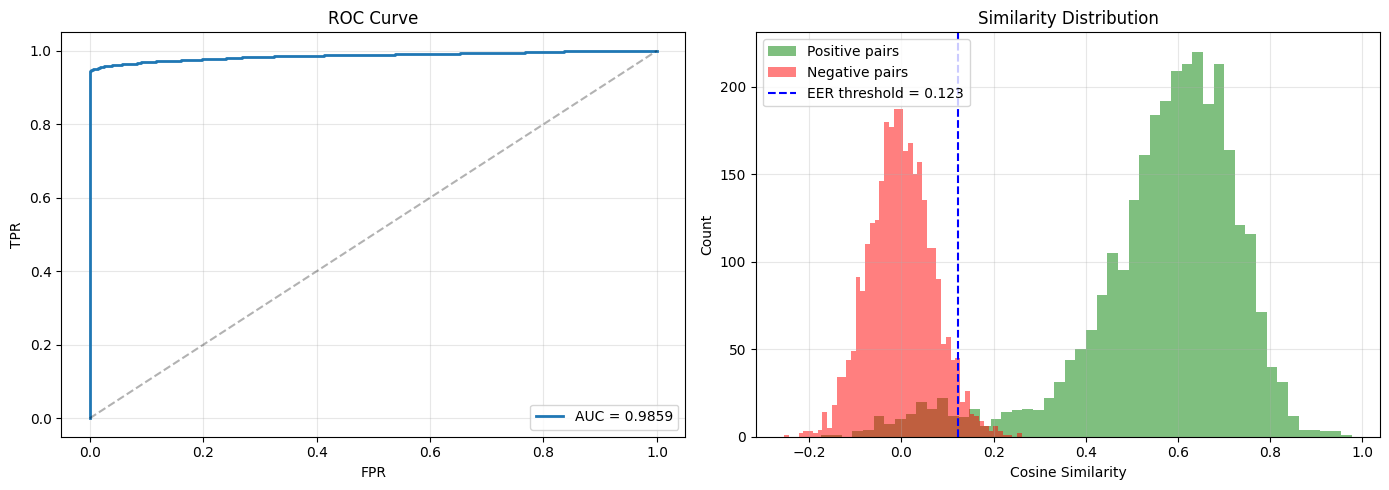

Wykresy zapisane: /content/drive/MyDrive/biometrics/face_authorization/results/evaluation_plots.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
axes[0].plot(
    test_metrics["fpr"], test_metrics["tpr"],
    linewidth=2, label=f"AUC = {test_metrics['auc']:.4f}",
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# --- Histogram podobieństwa ---
pos_sim = test_metrics["similarities"][test_metrics["labels"] == 1]
neg_sim = test_metrics["similarities"][test_metrics["labels"] == 0]

eer_thr_idx = np.argmin(np.abs(test_metrics["fpr"] - test_metrics["fnr"]))
eer_threshold = test_metrics["thresholds"][eer_thr_idx]

axes[1].hist(pos_sim, bins=50, alpha=0.5, label="Positive pairs", color="green")
axes[1].hist(neg_sim, bins=50, alpha=0.5, label="Negative pairs", color="red")
axes[1].axvline(
    x=eer_threshold, color="blue", linestyle="--",
    label=f"EER threshold = {eer_threshold:.3f}",
)
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Count")
axes[1].set_title("Similarity Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "evaluation_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Wykresy zapisane: {RESULTS_DIR / 'evaluation_plots.png'}")